### Basic Errorbars

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

<ErrorbarContainer object of 3 artists>

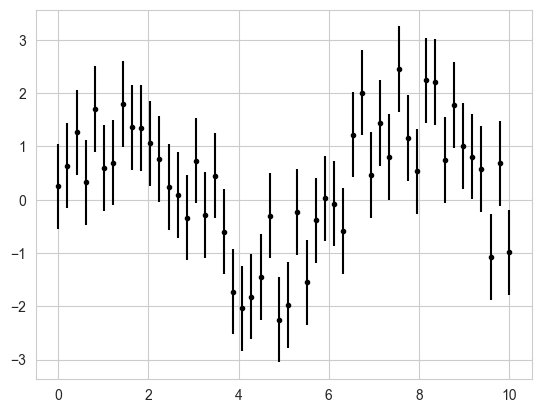

In [8]:
x = np.linspace(0, 10, 50)
dy = 0.8
y = np.sin(x) + dy * np.random.randn(50)
plt.errorbar(x, y, yerr=dy, fmt='.k') # fmt çizim noktalarının şeklini belirler

<ErrorbarContainer object of 3 artists>

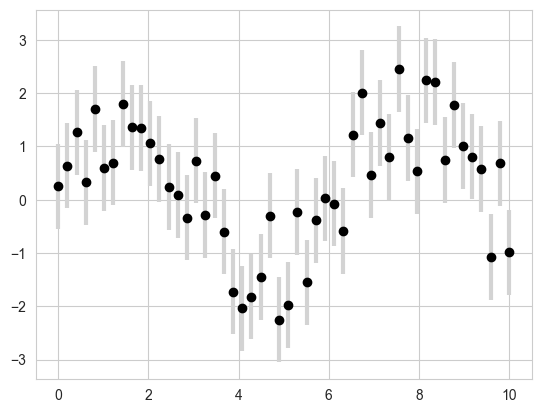

In [9]:
plt.errorbar(x, y, yerr=dy, fmt='o', color = 'black', ecolor='lightgray', elinewidth=3, capsize=0)

### Continuous Errors

In [11]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
model = lambda x: x * np.sin(x)
xdata = np.array([1, 3, 5, 6, 8])
ydata = model(xdata)

kernel = C(1.0) * RBF(length_scale=1.0)

gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, normalize_y=True)

gp.fit(xdata[:, np.newaxis], ydata)
xfit = np.linspace(0, 10, 1000)
yfit, std = gp.predict(xfit[:, None], return_std=True)

dyfit = 2 * std

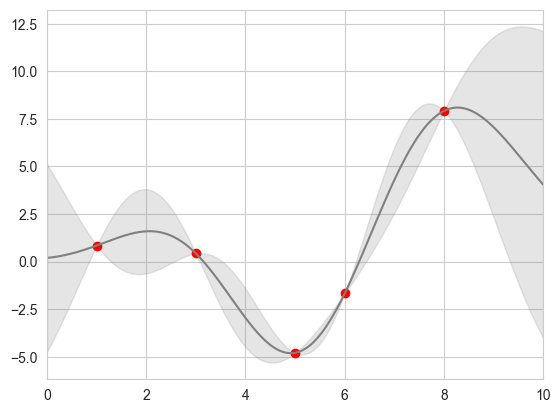

In [12]:
plt.plot(xdata, ydata, 'or')
plt.plot(xfit, yfit, '-', color='gray')
plt.fill_between(xfit, yfit - dyfit, yfit + dyfit, color='gray', alpha=0.2)
plt.xlim(0, 10)
plt.show()

### Density and Contour Plots

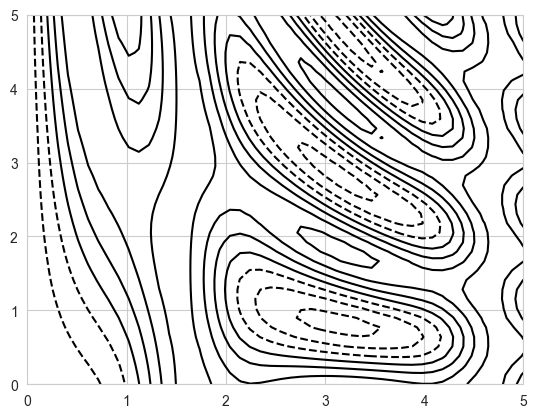

In [13]:
def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)
plt.contour(X, Y, Z, colors = 'black')

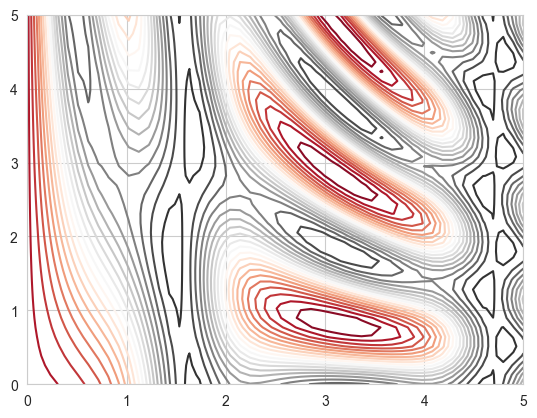

In [14]:
plt.contour(X, Y, Z, 20, cmap='RdGy')

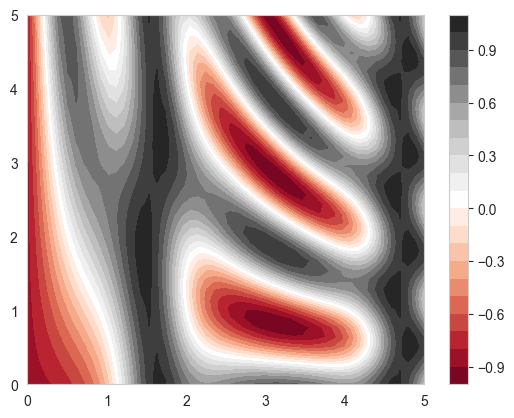

In [17]:
plt.contourf(X, Y, Z, 20,cmap ='RdGy')
plt.colorbar()

(np.float64(0.0), np.float64(5.0), np.float64(0.0), np.float64(5.0))

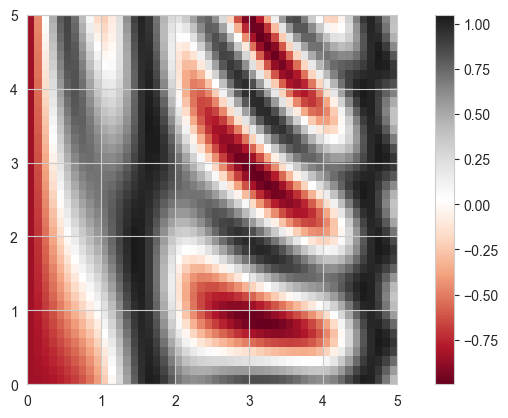

In [19]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy')
plt.colorbar()
plt.axis('image')

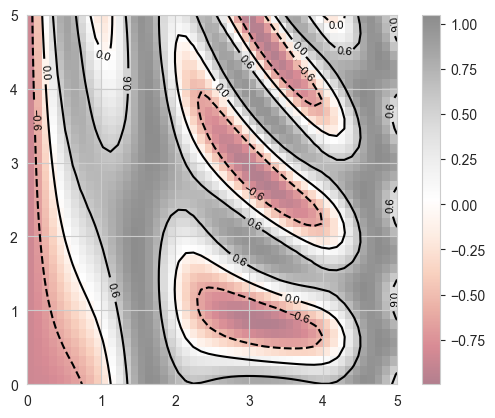

In [20]:
contours = plt.contour(X, Y, Z, 3, colors='black')
plt.clabel(contours, inline=True, fontsize=8)
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy', alpha=0.5)
plt.colorbar()

### Histograms, Binnings, and Density

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

(array([  1.,   9.,  43., 112., 221., 260., 203.,  99.,  36.,  16.]),
 array([-3.56134516, -2.91406114, -2.26677713, -1.61949312, -0.9722091 ,
        -0.32492509,  0.32235893,  0.96964294,  1.61692696,  2.26421097,
         2.91149499]),
 <BarContainer object of 10 artists>)

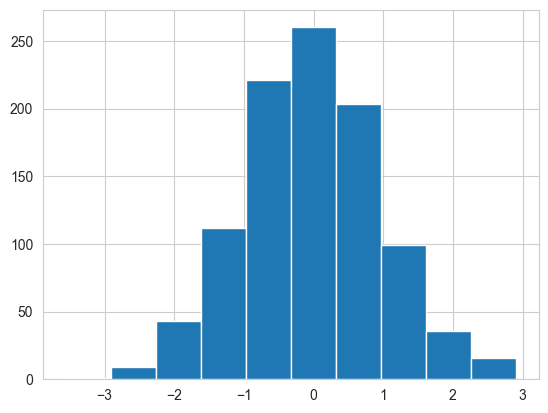

In [2]:
data = np.random.randn(1000)
plt.hist(data)

(array([  1.,   0.,   0.,   1.,   4.,   4.,   6.,  18.,  19.,  28.,  43.,
         41.,  74.,  69.,  78.,  88., 102.,  70.,  77.,  58.,  68.,  46.,
         35.,  18.,  14.,  16.,   6.,   9.,   4.,   3.]),
 array([-3.56134516, -3.34558382, -3.12982248, -2.91406114, -2.69829981,
        -2.48253847, -2.26677713, -2.05101579, -1.83525445, -1.61949312,
        -1.40373178, -1.18797044, -0.9722091 , -0.75644776, -0.54068642,
        -0.32492509, -0.10916375,  0.10659759,  0.32235893,  0.53812027,
         0.75388161,  0.96964294,  1.18540428,  1.40116562,  1.61692696,
         1.8326883 ,  2.04844964,  2.26421097,  2.47997231,  2.69573365,
         2.91149499]),
 [<matplotlib.patches.Polygon at 0x16eb8072ad0>])

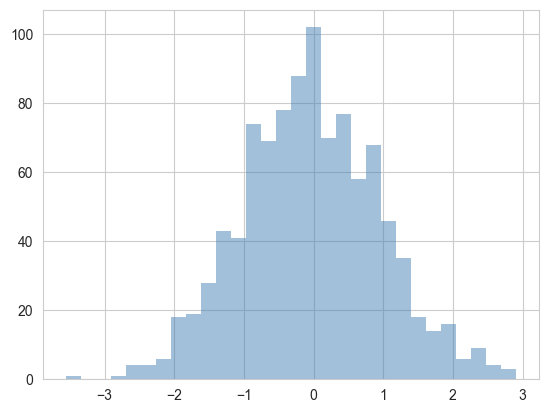

In [4]:
plt.hist(data, bins=30 , alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none')

(array([ 3.,  8.,  5.,  8., 10., 10., 20., 26., 23., 31., 34., 47., 30.,
        50., 53., 59., 51., 65., 54., 47., 51., 52., 47., 38., 41., 28.,
        20., 22., 23.,  8.,  6.,  7.,  6.,  8.,  4.,  3.,  1.,  0.,  0.,
         1.]),
 array([-2.19053389, -1.89741942, -1.60430494, -1.31119047, -1.01807599,
        -0.72496152, -0.43184704, -0.13873256,  0.15438191,  0.44749639,
         0.74061086,  1.03372534,  1.32683981,  1.61995429,  1.91306876,
         2.20618324,  2.49929771,  2.79241219,  3.08552666,  3.37864114,
         3.67175562,  3.96487009,  4.25798457,  4.55109904,  4.84421352,
         5.13732799,  5.43044247,  5.72355694,  6.01667142,  6.30978589,
         6.60290037,  6.89601485,  7.18912932,  7.4822438 ,  7.77535827,
         8.06847275,  8.36158722,  8.6547017 ,  8.94781617,  9.24093065,
         9.53404512]),
 [<matplotlib.patches.Polygon at 0x16eb8124b90>])

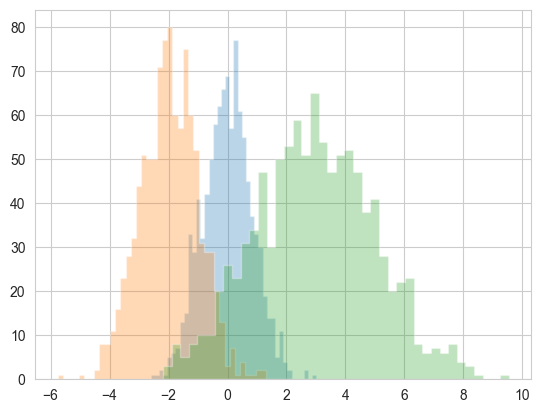

In [5]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)
plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs)

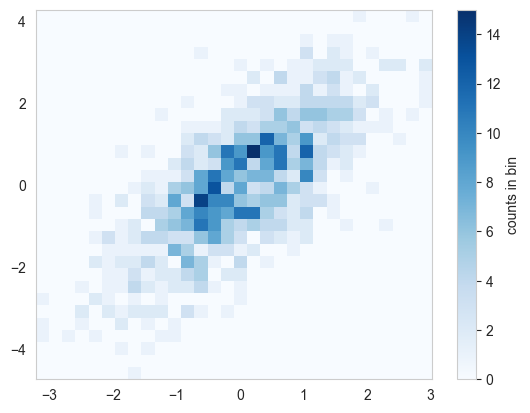

In [6]:
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 1000).T
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

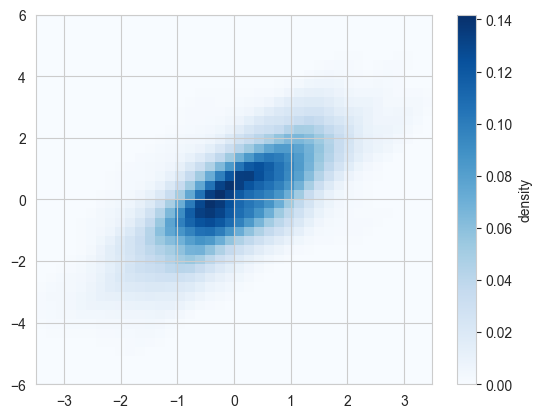

In [8]:
from scipy.stats import gaussian_kde

data = np.vstack([x, y])
kde = gaussian_kde(data)

xgrid = np.linspace(-3.5, 3.5, 40)
ygrid = np.linspace(-6, 6, 40)

Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
Z = kde.evaluate(np.vstack([Xgrid.ravel(), Ygrid.ravel()]))
plt.imshow(Z.reshape(Xgrid.shape),
origin='lower', aspect='auto',
extent=[-3.5, 3.5, -6, 6],
cmap='Blues')
cb = plt.colorbar()
cb.set_label("density")

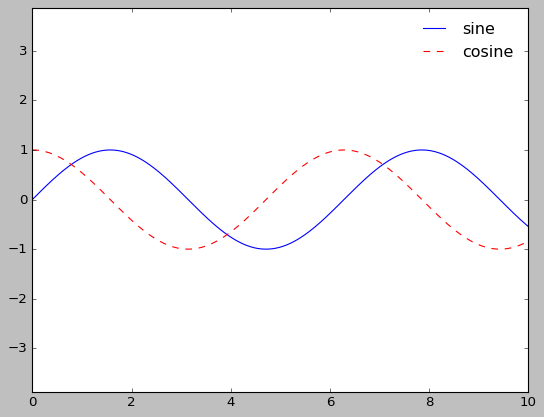

In [17]:
plt.style.use('classic')
x = np.linspace(0, 10, 1000)

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), '-b', label='sine')
ax.plot(x, np.cos(x), '--r', label='cosine')
ax.axis('equal')
leg = ax.legend(frameon=False, loc='upper right')

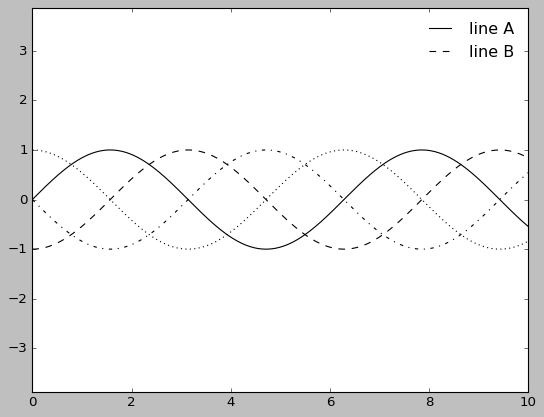

In [19]:
fig, ax = plt.subplots()
lines= []
styles = ['-', '--', '-.', ':']
x = np.linspace(0, 10, 1000)

for i in range(4):
    lines += ax.plot(x, np.sin(x-i * np.pi/2), styles[i], color = 'black')
ax.axis('equal')

ax.legend(lines[:2], ['line A', 'line B'], loc = 'upper right', frameon=False)

from matplotlib.legend import Legend

leg = Legend(ax, lines[2:], ['line C', 'line D'], loc = 'lower right', frameon=False)